# Model 1A, Experiment 01: Compact Engineered Random Forest

This notebook evaluates a Random Forest using the compact tree-oriented engineered representation for flights departing JFK. The target, `DepDel15`, equals 1 when departure delay is at least 15 minutes and 0 otherwise.

Random Forest Experiment 01 keeps the exact 34-field non-backlog feature manifest from Decision Tree Experiment 02. It uses the same population, expanding-window 2019 folds, metrics, training-only threshold procedure, and complete 2023 external development/validation dataset. The controlled change is replacing one tree with a bootstrap ensemble whose trees also receive random feature subsets.

The forest search varies the number and size of trees, the number of candidate features at each split, leaf regularization, and class weighting. Bootstrap sampling is always enabled, and out-of-bag scoring is retained as a diagnostic rather than used to select the model.

All preprocessing remains inside each training fold. The 2023 labels are used only after the model and threshold choices are fixed, and the 2024 dataset is not loaded.


In [1]:
# Parameters
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4


In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Load and validate the shared 2019 and 2023 departure feature data

The path lookup supports running from either the project root or the `models` directory. The explicit Random Forest Experiment 01 allowlist selects the same 34-feature tree-oriented subset used by Decision Tree Experiment 02 from the shared raw and Appendix B engineered departure data.


In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    """Return the nearest parent containing every requested feature file."""
    relative_paths = [
        Path("data/features") / f"{airport}_{year}_departures.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).exists() for path in relative_paths):
            return candidate
    raise FileNotFoundError(f"Could not locate all required files: {relative_paths}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_departures.csv"
VALIDATION_DATA_PATH = (
    PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_departures.csv"
)

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)

print(f"Training source: {TRAIN_DATA_PATH}")
print(f"Training rows: {len(train_df):,}; columns: {train_df.shape[1]:,}")
print(f"Validation source: {VALIDATION_DATA_PATH}")
print(f"Validation rows: {len(validation_df):,}; columns: {validation_df.shape[1]:,}")


Training source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2019_departures.csv
Training rows: 107,430; columns: 106
Validation source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2023_departures.csv
Validation rows: 109,983; columns: 106


In [4]:
def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    """Validate one source population and return its audit summary."""
    required_audit_columns = {"FlightDate", "Origin", TARGET}
    missing_audit_columns = sorted(required_audit_columns - set(frame.columns))
    assert not missing_audit_columns, f"{partition} missing audit columns: {missing_audit_columns}"

    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="coerce")
    assert frame["FlightDate"].notna().all(), f"{partition} has invalid FlightDate values"
    assert frame["FlightDate"].dt.year.eq(year).all(), f"{partition} has rows outside {year}"
    assert frame["Origin"].eq(AIRPORT).all(), f"{partition} Origin must equal {AIRPORT}"
    assert frame[TARGET].notna().all(), f"{partition} {TARGET} contains missing values"
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0}), (
        f"{partition} has unexpected {TARGET} values"
    )

    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame(
    [
        validate_source_frame(train_df, TRAIN_YEAR, "training"),
        validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
    ]
).set_index("partition")
source_summary


,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107430,20168,0.1877
external validation,2023,2023-01-01,2023-12-31,365,109983,25995,0.2364


## Compact tree-oriented engineered feature manifest

The manifest uses representations that bounded-depth trees can split directly or benefit from receiving as predefined summaries:

1. **Calendar, schedule, and identity:** raw month, weekday, scheduled HHMM values, elapsed time, and distance remain because trees depend on ordering rather than linear spacing. Coarse time-of-day, weekend, scheduled-speed, and airline-destination features add useful groupings and one controlled interaction.
2. **Planned airport demand:** all six previous/current/next scheduled departure and arrival counts remain. Three-hour directional totals, total-traffic slopes, and the maximum hourly traffic expose demand level, direction, trend, and peak without requiring the tree to spend several levels reconstructing them.
3. **Weather:** raw temperature, humidity, visibility, and wind speed are paired with dew-point spread, log precipitation, wind components, condition count, adverse-weather flag, and observation age.

Deliberate exclusions keep the set smaller than the broad 54-feature pool: `ROUTE` duplicates destination for JFK departures; `AIRLINE_FLIGHT_ID` is high cardinality; sine/cosine pairs are less natural for a single tree; log distance preserves the same ordering as raw distance; and three-hour total traffic duplicates the two directional totals. Actual operational and delay-outcome fields remain forbidden.


In [5]:
categorical_features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Dest",
    "TIME_OF_DAY",
    "AIRLINE_DEST",
]

numeric_features = [
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "IS_WEEKEND",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
    "WindX",
    "WindY",
    "WEATHER_CONDITION_COUNT",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

feature_columns = categorical_features + numeric_features
required_columns = ["FlightDate", "Origin", TARGET, *feature_columns]

assert len(feature_columns) == 34
assert len(feature_columns) == len(set(feature_columns)), "Duplicate feature names selected"
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing_columns = sorted(set(required_columns) - set(frame.columns))
    assert not missing_columns, f"{partition} missing required columns: {missing_columns}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelay",
    "DepDelayMinutes",
    "DepartureDelayGroups",
    "TaxiOut",
    "WheelsOff",
    "WheelsOn",
    "TaxiIn",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrDel15",
    "ArrivalDelayGroups",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
leaking_columns = sorted(forbidden_predictors.intersection(feature_columns))
assert not leaking_columns, f"Prediction-time-invalid features selected: {leaking_columns}"

intentionally_excluded = {
    "ROUTE",
    "AIRLINE_FLIGHT_ID",
    "YEAR_PERIOD",
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "MONTH_SIN",
    "MONTH_COS",
    "LOG_DISTANCE",
    "ASPM_THREE_HOUR_TOTAL_SCHEDULED_TRAFFIC",
}
unexpected_exclusions = sorted(intentionally_excluded.intersection(feature_columns))
assert not unexpected_exclusions, f"Intentionally excluded features selected: {unexpected_exclusions}"

print(f"Selected {len(feature_columns)} compact tree-oriented predictors")
print(f"  categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")


Selected 34 compact tree-oriented predictors
  categorical: 6
  numeric: 28


## Missingness and temporal partitions

All 2019 rows form the training dataset. Its calendar days are divided into six consecutive blocks; five expanding-window folds train on all earlier blocks and validate on the next block. After selection, grid search refits the winning pipeline on all 2019 rows. The separately loaded 2023 rows are evaluated only after that refit.

No row is dropped for a missing predictor. Categorical mode imputation and numeric median imputation are learned separately inside every training fold. Numeric missingness indicators are added only when a training fold contains a missing value.

In [6]:
def prepare_model_frame(source_frame: pd.DataFrame) -> pd.DataFrame:
    """Select columns, sort chronologically, and normalize input dtypes."""
    model_frame = source_frame[required_columns].copy()
    model_frame = model_frame.sort_values(
        ["FlightDate", "CRSDepTime"],
        kind="stable",
    ).reset_index(drop=True)
    model_frame[TARGET] = model_frame[TARGET].astype(int)

    for column in categorical_features:
        model_frame[column] = model_frame[column].astype(object)
    for column in numeric_features:
        model_frame[column] = pd.to_numeric(model_frame[column], errors="coerce")

    return model_frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)

missing_summary = pd.DataFrame(
    {
        "training_missing": train_model_df[feature_columns].isna().sum(),
        "validation_missing": validation_model_df[feature_columns].isna().sum(),
    }
)
display(missing_summary[missing_summary.sum(axis=1).gt(0)])

X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)

X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()


,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
ASPM_THREE_HOUR_SCHEDULED_DEPARTURES,1,0
ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,1,0
ASPM_NEXT_MINUS_CURRENT_TRAFFIC,1,0
ASPM_MAX_HOURLY_TRAFFIC,1,0
TEMP_DEWPOINT_SPREAD,46,0
LOG_PRECIPITATION,22,21
HourlyVisibility,0,28
WindX,54,87


In [7]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    """Create expanding train/validation indices without splitting calendar days."""
    normalized_dates = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized_dates)))

    if len(unique_days) < n_splits + 1:
        raise ValueError("Not enough unique days for the requested temporal folds")

    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits = []
    rows = []

    for fold_number in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold_number])
        validation_days = day_blocks[fold_number]
        train_indices = np.flatnonzero(np.isin(normalized_dates, train_days))
        validation_indices = np.flatnonzero(np.isin(normalized_dates, validation_days))

        assert train_indices.size and validation_indices.size
        assert train_days.max() < validation_days.min()
        splits.append((train_indices, validation_indices))
        rows.append(
            {
                "fold": fold_number,
                "train_start": pd.Timestamp(train_days.min()).date(),
                "train_end": pd.Timestamp(train_days.max()).date(),
                "validation_start": pd.Timestamp(validation_days.min()).date(),
                "validation_end": pd.Timestamp(validation_days.max()).date(),
                "train_rows": len(train_indices),
                "validation_rows": len(validation_indices),
                "train_delay_rate": targets.iloc[train_indices].mean(),
                "validation_delay_rate": targets.iloc[validation_indices].mean(),
            }
        )

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)

partition_summary = pd.DataFrame(
    {
        "start": [training_dates.min().date(), validation_dates.min().date()],
        "end": [training_dates.max().date(), validation_dates.max().date()],
        "days": [
            training_dates.dt.normalize().nunique(),
            validation_dates.dt.normalize().nunique(),
        ],
        "rows": [len(y_train), len(y_validation)],
        "delayed_flights": [y_train.sum(), y_validation.sum()],
        "delay_rate": [y_train.mean(), y_validation.mean()],
    },
    index=["2019 training", "2023 external validation"],
)

display(partition_summary)
fold_summary


,start,end,days,rows,delayed_flights,delay_rate
2019 training,2019-01-01,2019-12-31,365,107430,20168,0.1877
2023 external validation,2023-01-01,2023-12-31,365,109983,25995,0.2364


,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_delay_rate,validation_delay_rate
fold,,,,,,,,
1,2019-01-01,2019-03-02,2019-03-03,2019-05-02,17737,18776,0.1892,0.1674
2,2019-01-01,2019-05-02,2019-05-03,2019-07-02,36513,18150,0.1780,0.2072
3,2019-01-01,2019-07-02,2019-07-03,2019-09-01,54663,17758,0.1877,0.2577
4,2019-01-01,2019-09-01,2019-09-02,2019-11-01,72421,17686,0.2048,0.1384
5,2019-01-01,2019-11-01,2019-11-02,2019-12-31,90107,17323,0.1918,0.1666


## Preprocessing and controlled Random Forest search

Categorical mode imputation, one-hot encoding, numeric median imputation, and missingness indicators are part of the pipeline. Every learned transformation is therefore fitted only on the training portion of each temporal fold.

The compact 32-configuration grid tests:

- 200 and 400 trees;
- maximum depths of 10 and 15;
- minimum leaf sizes of 100 and 500;
- square-root and 50% feature sampling at each split;
- no class weighting and fold-specific `balanced_subsample` weighting.

The deliberately regularized trees keep computation practical and follow the successful single-tree ranges. The forest runs one fit per process while grid search parallelizes across four candidates, avoiding nested parallelism. Average precision selects the configuration; neither out-of-bag score nor 2023 outcomes are used for tuning.


In [8]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numeric", numeric_pipeline, numeric_features),
    ],
    remainder="drop",
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                criterion="gini",
                bootstrap=True,
                oob_score=True,
                n_jobs=1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

parameter_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [10, 15],
    "classifier__min_samples_leaf": [100, 500],
    "classifier__max_features": ["sqrt", 0.5],
    "classifier__class_weight": [None, "balanced_subsample"],
}

scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=1,
    return_train_score=False,
    error_score="raise",
)

parameter_count = len(list(ParameterGrid(parameter_grid)))
print(f"Hyperparameter combinations: {parameter_count:,}")
print(f"Temporal cross-validation fits: {parameter_count * len(temporal_splits):,}")


Hyperparameter combinations: 32
Temporal cross-validation fits: 160


In [9]:
search_start = perf_counter()
grid_search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start

best_random_forest_pipeline = grid_search.best_estimator_
fitted_forest = best_random_forest_pipeline.named_steps["classifier"]

print(f"Grid search and refit completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation average precision: {grid_search.best_score_:.4f}")
print(f"Refitted forest trees: {len(fitted_forest.estimators_):,}")
print(f"Out-of-bag accuracy diagnostic: {fitted_forest.oob_score_:.4f}")
print("Best parameters:")
display(pd.Series(grid_search.best_params_, name="value").to_frame())


Fitting 5 folds for each of 32 candidates, totalling 160 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Grid search and refit completed in 1,057.9 seconds
Best mean temporal-validation average precision: 0.3327
Refitted forest trees: 400
Out-of-bag accuracy diagnostic: 0.8162
Best parameters:


,value
classifier__class_weight,None
classifier__max_depth,15
classifier__max_features,sqrt
classifier__min_samples_leaf,100
classifier__n_estimators,400


In [10]:
cv_results = pd.DataFrame(grid_search.cv_results_)

result_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_mcc",
    "mean_test_neg_brier",
    "param_classifier__n_estimators",
    "param_classifier__max_depth",
    "param_classifier__min_samples_leaf",
    "param_classifier__max_features",
    "param_classifier__class_weight",
]

display(
    cv_results.sort_values("rank_test_average_precision")[result_columns].head(12)
)

complexity_comparison = (
    cv_results.groupby(
        ["param_classifier__max_features", "param_classifier__class_weight"],
        dropna=False,
    )
    .agg(
        best_mean_average_precision=("mean_test_average_precision", "max"),
        best_mean_roc_auc=("mean_test_roc_auc", "max"),
        best_mean_neg_brier=("mean_test_neg_brier", "max"),
        candidates=("mean_test_average_precision", "size"),
    )
    .sort_values("best_mean_average_precision", ascending=False)
)
complexity_comparison.head(12)


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_mcc,mean_test_neg_brier,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__class_weight
9,1,0.3327,0.0749,0.6817,0.5012,0.3585,0.0027,0.0053,0.0253,-0.1428,400,15,100,sqrt,NaN
15,2,0.3320,0.0706,0.6833,0.5093,0.2218,0.0230,0.0417,0.0520,-0.1429,400,15,500,0.5000,NaN
14,3,0.3320,0.0707,0.6833,0.5093,0.2215,0.0229,0.0415,0.0516,-0.1429,200,15,500,0.5000,NaN
1,4,0.3314,0.0754,0.6790,0.5003,0.1429,0.0007,0.0013,0.0072,-0.1432,400,10,100,sqrt,NaN
7,5,0.3311,0.0707,0.6828,0.5094,0.2174,0.0234,0.0423,0.0514,-0.1430,400,10,500,0.5000,NaN
8,6,0.3311,0.0758,0.6807,0.5012,0.3755,0.0025,0.0050,0.0255,-0.1429,200,15,100,sqrt,NaN
6,7,0.3307,0.0708,0.6827,0.5093,0.2222,0.0230,0.0417,0.0519,-0.1431,200,10,500,0.5000,NaN
31,8,0.3304,0.0708,0.6833,0.6302,0.2900,0.6068,0.3878,0.2093,-0.2158,400,15,500,0.5000,balanced_subsample
25,9,0.3302,0.0769,0.6814,0.6333,0.2835,0.6427,0.3899,0.2111,-0.2161,400,15,100,sqrt,balanced_subsample
30,10,0.3302,0.0702,0.6833,0.6296,0.2896,0.6062,0.3873,0.2084,-0.2158,200,15,500,0.5000,balanced_subsample


best_mean_average_precision  \
param_classifier__max_features param_classifier__class_weight                                
 sqrt                          NaN                                                  0.3327   
0.5000                         NaN                                                  0.3320   
                               balanced_subsample                                   0.3304   
 sqrt                          balanced_subsample                                   0.3302   

                                                               best_mean_roc_auc  \
param_classifier__max_features param_classifier__class_weight                      
 sqrt                          NaN                                        0.6817   
0.5000                         NaN                                        0.6833   
                               balanced_subsample                         0.6833   
 sqrt                          balanced_subsample                         0.6814   

                                                               best_mean_neg_brier  \
param_classifier__max_features param_classifier__class_weight                        
 sqrt                          NaN                                         -0.1428   
0.5000                         NaN                                         -0.1429   
                               balanced_subsample                          -0.2106   
 sqrt                          balanced_subsample                          -0.2161   

                                                               candidates  
param_classifier__max_features param_classifier__class_weight              
 sqrt                          NaN                                      8  
0.5000                         NaN                                      8  
                               balanced_subsample                       8  
 sqrt                          balanced_subsample                       8

In [11]:
encoded_feature_names = (
    best_random_forest_pipeline.named_steps["preprocessor"].get_feature_names_out()
)

forest_depths = np.array([tree.get_depth() for tree in fitted_forest.estimators_])
forest_leaves = np.array([tree.get_n_leaves() for tree in fitted_forest.estimators_])

forest_summary = pd.Series(
    {
        "source_predictors": len(feature_columns),
        "encoded_predictors": len(encoded_feature_names),
        "trees": len(fitted_forest.estimators_),
        "mean_tree_depth": forest_depths.mean(),
        "maximum_tree_depth": forest_depths.max(),
        "mean_terminal_leaves": forest_leaves.mean(),
        "oob_accuracy": fitted_forest.oob_score_,
    },
    name="value",
)
forest_summary.to_frame()


,value
source_predictors,34.0000
encoded_predictors,265.0000
trees,400.0000
mean_tree_depth,15.0000
maximum_tree_depth,15.0000
mean_terminal_leaves,297.8675
oob_accuracy,0.8162


## Select a classification threshold using 2019 only

Average precision and ROC AUC evaluate probability ranking, but operational labels require a threshold. The best pipeline is cloned and refitted once per temporal fold. Each validation row receives a probability from a model trained only on earlier days.

Thresholds from 0.05 through 0.50 are compared on these out-of-fold temporal predictions. The threshold with the highest F1 is selected, with balanced accuracy and then precision used only as tie-breakers. No 2023 label is used for threshold selection.

Threshold-selection rows: 89,693
Training-only selected threshold: 0.21


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
16,0.2100,0.6493,0.6299,0.2895,0.5989,0.3903,0.2081
15,0.2000,0.6224,0.6304,0.2796,0.6432,0.3897,0.2056
14,0.1900,0.5962,0.6310,0.2717,0.6868,0.3893,0.2048
17,0.2200,0.6762,0.6264,0.3002,0.5468,0.3876,0.2081
13,0.1800,0.5705,0.6286,0.2638,0.7215,0.3864,0.2008
12,0.1700,0.5440,0.6239,0.2560,0.7518,0.3820,0.1944
18,0.2300,0.7000,0.6200,0.3105,0.4920,0.3807,0.2050
11,0.1600,0.5187,0.6192,0.2494,0.7800,0.3779,0.1889
10,0.1500,0.4936,0.6140,0.2433,0.8066,0.3739,0.1834
19,0.2400,0.7217,0.6111,0.3209,0.4340,0.3690,0.1993


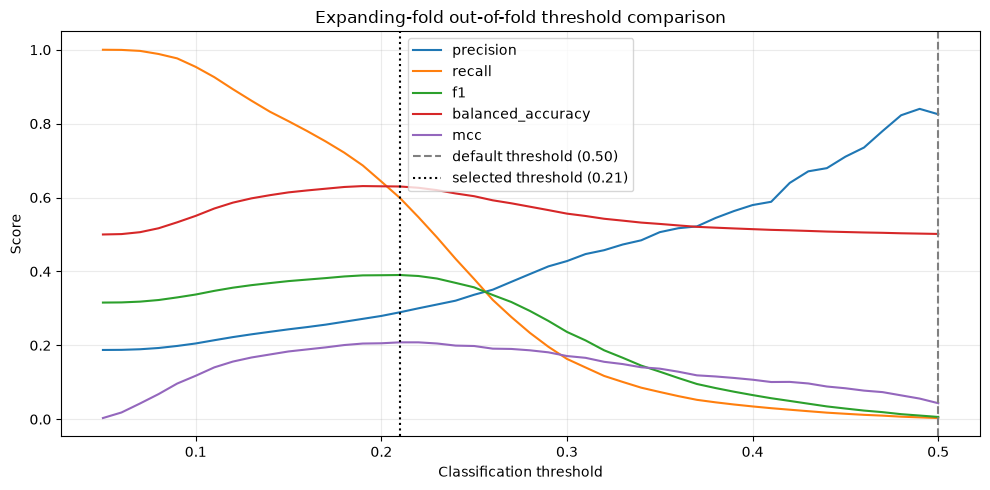

In [12]:
oof_probabilities = np.full(len(y_train), np.nan)

for train_indices, validation_indices in temporal_splits:
    fold_model = clone(best_random_forest_pipeline)
    fold_model.fit(
        X_train.iloc[train_indices],
        y_train.iloc[train_indices],
    )
    oof_probabilities[validation_indices] = fold_model.predict_proba(
        X_train.iloc[validation_indices]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
assert oof_mask.sum() > 0
assert np.isfinite(oof_probabilities[oof_mask]).all()

candidate_thresholds = np.round(np.arange(0.05, 0.501, 0.01), 2)
threshold_rows = []
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]

for threshold in candidate_thresholds:
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(oof_y, predictions),
            "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
            "precision": precision_score(oof_y, predictions, zero_division=0),
            "recall": recall_score(oof_y, predictions, zero_division=0),
            "f1": f1_score(oof_y, predictions, zero_division=0),
            "mcc": matthews_corrcoef(oof_y, predictions),
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
display(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["precision", "recall", "f1", "balanced_accuracy", "mcc"]:
    ax.plot(threshold_results["threshold"], threshold_results[metric], label=metric)

ax.axvline(0.50, color="gray", linestyle="--", label="default threshold (0.50)")
ax.axvline(
    selected_threshold,
    color="black",
    linestyle=":",
    label=f"selected threshold ({selected_threshold:.2f})",
)
ax.set(
    title="Expanding-fold out-of-fold threshold comparison",
    xlabel="Classification threshold",
    ylabel="Score",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Evaluate the 2023 external validation dataset

The grid-selected estimator was refitted automatically on all 2019 training rows. It is now evaluated on 2023 at both the default 0.50 threshold and the threshold selected from 2019 out-of-fold probabilities. The class-prior dummy provides the no-skill reference.

Threshold changes affect label metrics such as precision and recall, but they do not change average precision, ROC AUC, or Brier score.

In [13]:
def evaluate_probabilities(y_true, probabilities, model_name, threshold):
    """Return threshold, ranking, correlation, and calibration metrics."""
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


validation_probabilities = best_random_forest_pipeline.predict_proba(X_validation)[:, 1]

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train, y_train)
dummy_probabilities = dummy_model.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame(
    [
        evaluate_probabilities(
            y_validation,
            dummy_probabilities,
            "Dummy (2019 class prior)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Random forest (default threshold)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Random forest (training-selected threshold)",
            selected_threshold,
        ),
    ]
).set_index("model")

evaluation_results


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Dummy (2019 class prior),0.5000,0.7636,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2364,0.1829
Random forest (default threshold),0.5000,0.7643,0.5022,0.6818,0.0052,0.0103,0.0445,0.6812,0.3970,0.1700
Random forest (training-selected threshold),0.2100,0.6594,0.6308,0.3616,0.5766,0.4445,0.2293,0.6812,0.3970,0.1700


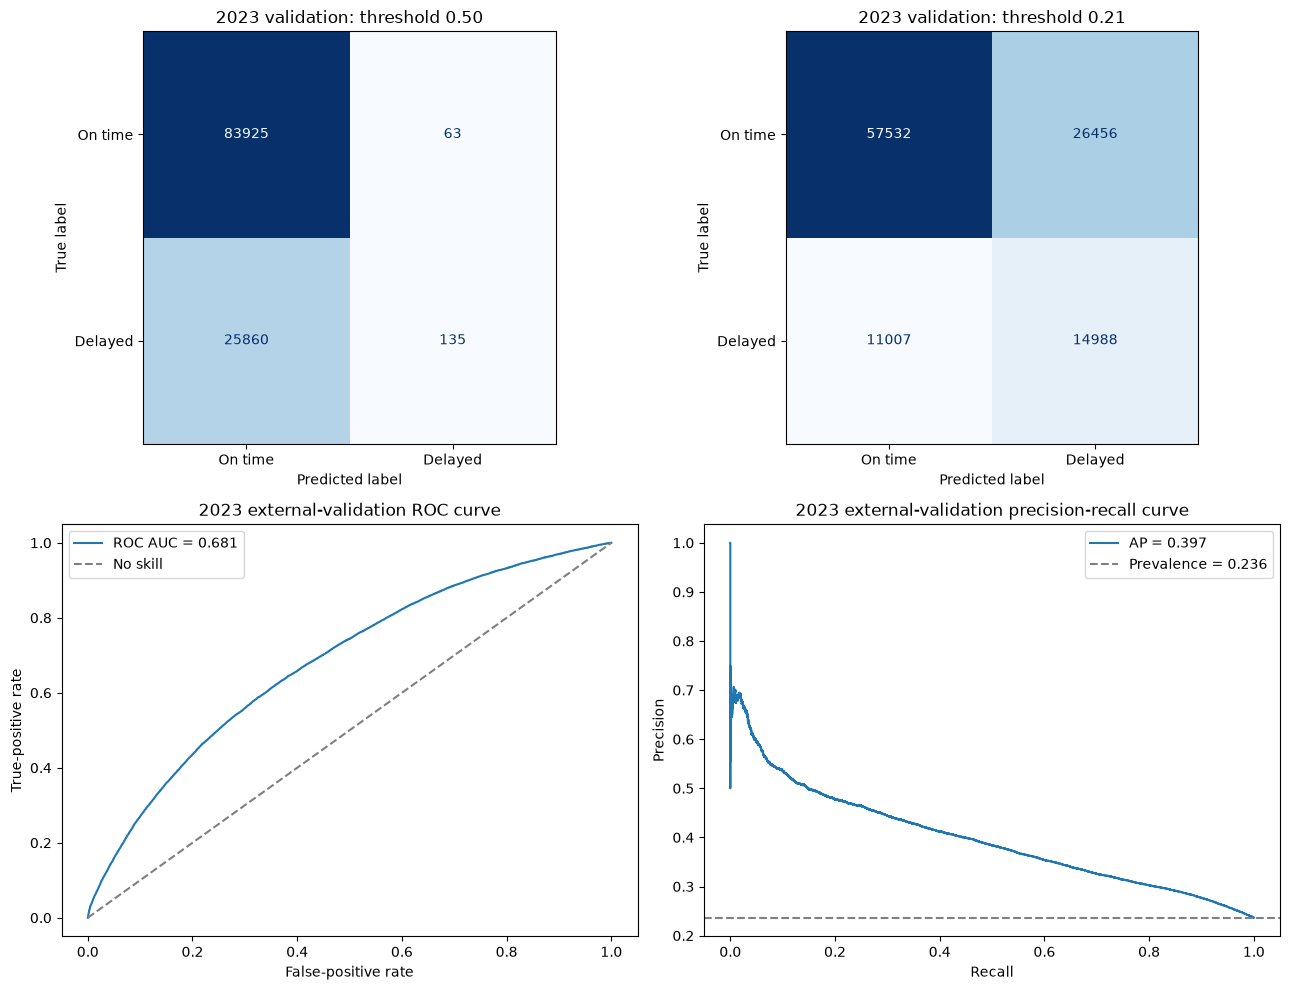

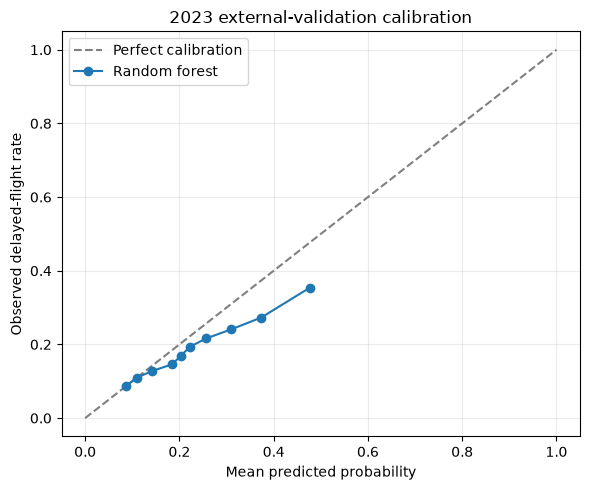

In [14]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)

false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
calibration_predicted, calibration_observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023 validation: threshold 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023 validation: threshold {selected_threshold:.2f}")

axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC AUC = {roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="2023 external-validation ROC curve",
)
axes[1, 0].legend()

axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP = {average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalence = {y_validation.mean():.3f}",
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="2023 external-validation precision-recall curve",
)
axes[1, 1].legend()

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(
    calibration_predicted,
    calibration_observed,
    marker="o",
    label="Random forest",
)
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delayed-flight rate",
    title="2023 external-validation calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Inspect impurity-based feature importance

The fitted forest averages impurity reduction across its trees. The first table shows encoded columns; the second aggregates one-hot categories back to their source predictor. Impurity importance is descriptive rather than causal and can favor predictors with more possible split points.


In [15]:
def source_feature_from_encoded_name(encoded_name: str) -> str:
    """Map a ColumnTransformer output name back to its source column."""
    transformer_name, transformed_name = encoded_name.split("__", 1)
    if transformer_name == "numeric":
        return transformed_name.removeprefix("missingindicator_")

    for source_name in sorted(categorical_features, key=len, reverse=True):
        if transformed_name == source_name or transformed_name.startswith(f"{source_name}_"):
            return source_name
    return transformed_name


importance_table = (
    pd.DataFrame(
        {
            "encoded_feature": encoded_feature_names,
            "importance": fitted_forest.feature_importances_,
        }
    )
    .assign(
        source_feature=lambda frame: frame["encoded_feature"].map(
            source_feature_from_encoded_name
        )
    )
    .sort_values("importance", ascending=False)
)

source_importance = (
    importance_table.groupby("source_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(importance_table.head(20))
source_importance.head(20)


,encoded_feature,importance,source_feature
227,numeric__CRSDepTime,0.0908,CRSDepTime
240,numeric__ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,0.0618,ASPM_THREE_HOUR_SCHEDULED_ARRIVALS
228,numeric__CRSArrTime,0.0528,CRSArrTime
247,numeric__HourlyRelativeHumidity,0.0518,HourlyRelativeHumidity
245,numeric__TEMP_DEWPOINT_SPREAD,0.0478,TEMP_DEWPOINT_SPREAD
244,numeric__HourlyDryBulbTemperature,0.0469,HourlyDryBulbTemperature
236,numeric__ASPM_CURRENT_SCHEDULED_ARRIVALS,0.0454,ASPM_CURRENT_SCHEDULED_ARRIVALS
81,categorical__TIME_OF_DAY_morning,0.0437,TIME_OF_DAY
234,numeric__ASPM_PREVIOUS_SCHEDULED_ARRIVALS,0.0418,ASPM_PREVIOUS_SCHEDULED_ARRIVALS
243,numeric__ASPM_MAX_HOURLY_TRAFFIC,0.0411,ASPM_MAX_HOURLY_TRAFFIC


,source_feature,importance
14,CRSDepTime,0.0908
30,TIME_OF_DAY,0.0834
11,ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,0.0618
13,CRSArrTime,0.0528
20,HourlyRelativeHumidity,0.0518
25,Month,0.0510
29,TEMP_DEWPOINT_SPREAD,0.0478
19,HourlyDryBulbTemperature,0.0469
3,ASPM_CURRENT_SCHEDULED_ARRIVALS,0.0454
9,ASPM_PREVIOUS_SCHEDULED_ARRIVALS,0.0418


## Visualize leading source-feature importance

The chart aggregates one-hot categories and missingness indicators back to the 15 most important source fields. It describes the fitted forest but does not establish causal effects.


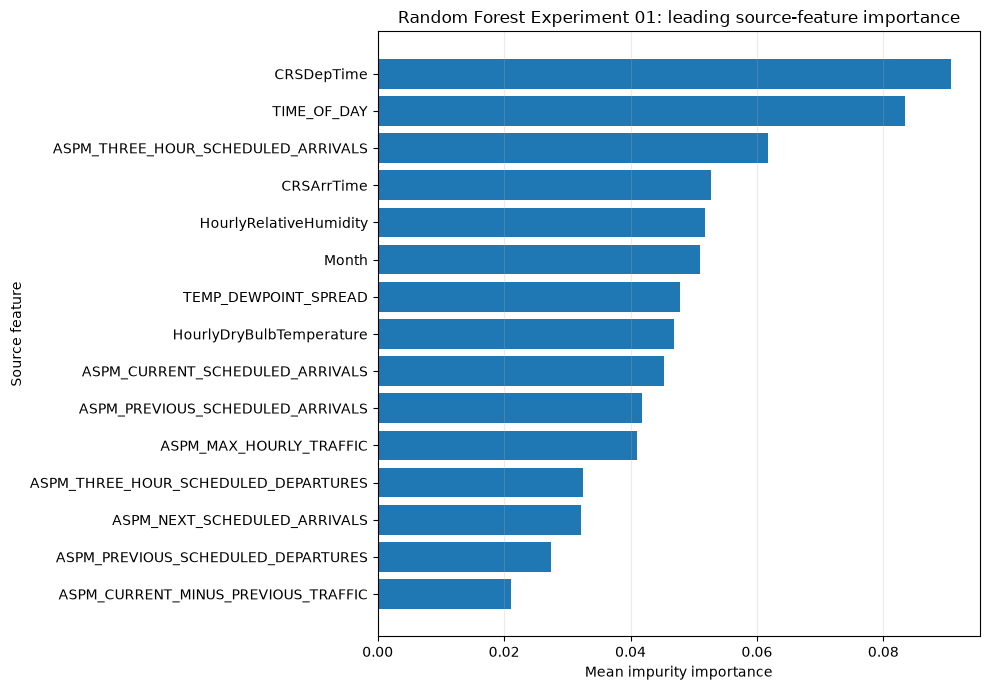

In [16]:
top_source_importance = source_importance.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_source_importance["source_feature"], top_source_importance["importance"])
ax.set(
    title="Random Forest Experiment 01: leading source-feature importance",
    xlabel="Mean impurity importance",
    ylabel="Source feature",
)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## Random Forest Experiment 01 interpretation checklist

Use the displayed results to compare the compact engineered forest with Decision Tree Experiment 02 and the completed logistic-regression baselines:

1. Did averaging randomized trees improve 2019 temporal-validation and 2023 external-validation average precision over the single tree?
2. Did ROC AUC, Brier score, and calibration improve along with average precision?
3. Which tree count, depth, leaf size, feature-sampling rule, and class-weight treatment won?
4. Did engineered congestion summaries receive material importance beyond their six raw ASPM inputs?
5. Did the training-selected threshold improve the 2023 precision/recall trade-off?
6. Is the forest improvement large enough to justify its added training and prediction cost?

Treat 2023 as an external development/validation year: its results must not be used to refit or tune this experiment. Compare Random Forest Experiment 01 with Decision Tree Experiment 02 using their identical feature manifest, folds, target population, validation rows, metrics, and threshold policy. The 2024 dataset remains locked for final evaluation.
